# Lab | Introduction to LoRA Tuning using PEFT from Hugging Face
<!-- ### Fine-tune a Foundational Model effortlessly -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.


# LoRA Tuning

In this notebook you are being introduced to how to apply LoRA Tuning with the PEFT library to a pre-trained model.

For a complete list of Models compatible with PEFT refer to their [documentation](https://huggingface.co/docs/peft/main/en/index#supported-methods).

A short sample of models families available to be trained with PEFT are: Bloom, Llama, GPT-J, GPT-2, BERT... and more. Hugging Face is working hard to bring more Models to the Library.

## Brief introduction to LoRA Tuning.
LoRA is a re-parameterization technique. Its operation is simple, complex, and brilliant at the same time. It involves reducing the size of the matrices to be trained by dividing them in such a way that when multiplied, they yield the original matrix.

The weights that are modified are those of the reduced matrices, not the original matrix. It's better visualized in an image.

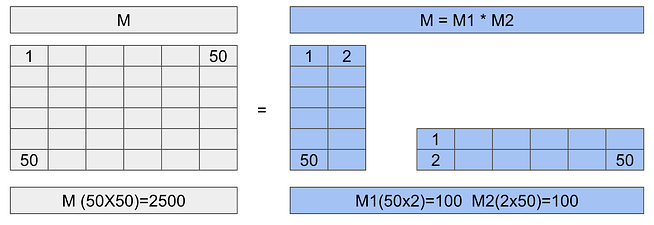

We have an original matrix of 50x50, which means we would have to modify about 2500 parameters. However, as we know, if we multiply two matrices of (2x50) and (50x2), we obtain a 50x50 matrix. Yet, these two matrices are formed by only 100 parameters each. In other words, for the reduced matrices, we need to modify a total of 200 parameters compared to the 2500 of the original matrix. This represents a 92% reduction, and the larger the original matrix, the greater the percentage of savings.

In Language Models like GPT-3 or any of the current ones with LoRA, it's possible that we only need to train about 0.02% of the original parameters. This varies for each model. The best part is that the obtained result is very similar to that of full fine-tuning, in some cases, it can even be better.

# Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [ ]:
# !pip install -q peft==0.8.2
# !pip install -q datasets==2.16.1
# !pip install ipywidgets==7.7.5

From the transformers library we import the necesary classes to import the model and the tokenizer.

Then we can load the Tokenizer and the model.

Bloom is one of the smallest and smarter model available to be trained with PEFT Library using Prompt Tuning. You can use either of the models in the Bloom Family, I encorage you to use at least two of them and see the differences.

I'm using the smallest one just to spend less time trainig, and avoid memory problems in Colab.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "bigscience/bloom-560m"
# I tried bigscience/bloom-1b1 but it didn't finalize after 40 min, so I will compare bigscience/bloom-560m with different variables

tokenizer = AutoTokenizer.from_pretrained(model_name)
foundation_model = AutoModelForCausalLM.from_pretrained(model_name)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [ ]:
#this function returns the outputs from the model received, and inputs.
def get_outputs(model, inputs, max_new_tokens=100): #play with this function inputs and see if you get something interesting
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5, #Avoid repetition.
        early_stopping=True, #The model can stop before reach the max_length
        eos_token_id=tokenizer.eos_token_id
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [ ]:
#Inference original model
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt")
foundational_outputs_sentence = get_outputs(foundation_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

[transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


["I want you to act as a motivational coach.  I know that is not what you're doing, but it's the way it should be done.\nYou have no idea how much time and effort I've put into this project. You don't even realize my efforts are worth anything if they aren't invaluable.\n\nA:"]


In [ ]:
# Format output with indentation and line breaks
print("Model Output:")
for output in tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True):
    # Strip extra whitespace and add proper indentation
    formatted_output = output.strip()
    print(f"\n{formatted_output}")

Model Output:

I want you to act as a motivational coach.  I know that is not what you're doing, but it's the way it should be done.
You have no idea how much time and effort I've put into this project. You don't even realize my efforts are worth anything if they aren't invaluable.

A:


Not sure if the answer is correct or not, but for sure is not a prompt. We need to train our model if we want that acts like a prompt engineer.

# Preparing the Dataset.
The Dataset used is:

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts

In [ ]:
from datasets import load_dataset
dataset = "fka/awesome-chatgpt-prompts"

#Create the Dataset to create prompts.
data = load_dataset(dataset)
data = data.map(lambda samples: tokenizer(samples["prompt"]), batched=True)
train_sample = data["train"].select(range(50))

train_sample = train_sample.remove_columns('act')

display(train_sample)

README.md:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

prompts.csv:   0%|          | 0.00/5.03M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1874 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'for_devs', 'type', 'contributor', 'input_ids', 'attention_mask'],
    num_rows: 50
})

In [ ]:
print(train_sample[:1])

{'prompt': ['Imagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.'], 'for_devs': [True], 'type': ['TEXT'], 'contributor': ['ameya-2003'], 'input_ids': [[186402, 1152, 1306, 660, 72560, 28857, 167625, 84544, 20165, 376, 1002, 26168, 267, 30479, 17477, 613, 267, 120755, 238776, 17, 1387, 47881, 632, 427, 14565, 29866, 664, 368, 120755, 15, 16997, 4054, 136044, 375, 4859, 12, 427, 39839, 15, 9697, 1242, 375, 13614, 12, 3804, 427, 368, 2298, 5268, 109891, 368, 17477, 15, 53

# Fine-Tuning.
First is necesary create a LoRA config.


In [ ]:
# TARGET_MODULES
# https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220

import peft
from peft import LoraConfig, get_peft_model, PeftModel

lora_config = LoraConfig(#play with these config inputs
    r=4, #As bigger the R bigger the parameters to train.
    lora_alpha=1, # a scaling factor that adjusts the magnitude of the weight matrix. Usually set to 1
    target_modules=["query_key_value"], #You can obtain a list of target modules in the URL above.
    lora_dropout=0.05, #Helps to avoid Overfitting.
    bias="lora_only", # this specifies if the bias parameter should be trained.
    task_type="CAUSAL_LM"
)

The most important parameter is **r**, it defines how many parameters will be trained. As bigger the valuer more parameters are trained, but it means that the model will be able to learn more complicated relations between input and output.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

### Create the PEFT model.



In [ ]:
!pip install --upgrade torchao
peft_model = get_peft_model(foundation_model, lora_config)
print(peft_model.print_trainable_parameters())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


trainable params: 466,944 || all params: 559,607,808 || trainable%: 0.0834
None


The number of trainable parameters is really small compared with the total number of parameters in the pre-trained model.

In [ ]:
#Create a directory to contain the Model
import os
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [ ]:
#Creating the TrainingArgs
import transformers
from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(
    output_dir=output_directory,
    auto_find_batch_size=True, # Find a correct bvatch size that fits the size of Data.
    learning_rate= 3e-2, # Higher learning rate than full fine-tuning.
    num_train_epochs=2,
    use_cpu=False
)

Now we can train the model.
To train the model we need:


*   The PEFT Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.





In [ ]:
#This cell may take up to 15 minutes to execute.
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_sample,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)
trainer.train()

Step,Training Loss


TrainOutput(global_step=14, training_loss=0.0, metrics={'train_runtime': 3.0795, 'train_samples_per_second': 32.473, 'train_steps_per_second': 4.546, 'total_flos': 20483556163584.0, 'train_loss': 0.0, 'epoch': 2.0})

In [ ]:
#Save the model.
peft_model_path = os.path.join(output_directory, f"lora_model")

trainer.model.save_pretrained(peft_model_path)

In [ ]:
#Load the Model.
loaded_model = PeftModel.from_pretrained(foundation_model,
                                        peft_model_path,
                                        is_trainable=False)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


## Inference the fine-tuned model.

In [ ]:
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(loaded_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

['I want you to act as a motivational coach. ']


In [ ]:
# Compare fine-tuned model output with baseline
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')

# Generate with the fine-tuned LoRA model
fine_tuned_outputs = get_outputs(loaded_model, input_sentences, max_new_tokens=50)

# Print results with clear labeling and formatting
print("\n=== FINE-TUNED MODEL OUTPUT ===")
print(f"{tokenizer.batch_decode(fine_tuned_outputs, skip_special_tokens=True)[0]}")
print("================================\n")


=== FINE-TUNED MODEL OUTPUT ===
I want you to act as a motivational coach. 



In [ ]:
fine_tuned_output = tokenizer.batch_decode(fine_tuned_outputs, skip_special_tokens=True)[0]

# Print with clear headers and separators
print("\n" + "="*50)
print("Pretrained Model Output:")
print("-"*50)
print(formatted_output)

print("\n\n" + "="*50)
print("Fine-Tuned Model Output:")
print("-"*50)
print(fine_tuned_output)
print("="*50)


Pretrained Model Output:
--------------------------------------------------
I want you to act as a motivational coach.  I know that is not what you're doing, but it's the way it should be done.
You have no idea how much time and effort I've put into this project. You don't even realize my efforts are worth anything if they aren't invaluable.

A:


Fine-Tuned Model Output:
--------------------------------------------------
I want you to act as a motivational coach. 


The result is amazing. Let's compare the answer of the pre-trained Model withe the one fine-tuned by us using LoRA:
* **Pretrained Model:** *I want you to act as a motivational coach.*  Don't be afraid of being challenged.
* **Fine-Tuned Model:** I want you to act as a motivational coach.  I will provide some information about someone\'s motivation and goals, but it should be your job  in order my first request – "I need someone who can help me find the best way for myself stay motivated when competing against others." My suggestion is “I have

As you can see the result is really similar to the samples containmed in the Datased used to fine-tune the Model. And we only trained the Model for 10 epochs and with a really small number of rows.

# Exercise

- Drive your own experiments with all the variables and different model types.
    - Please with the **lora_config** values, maybe you can achieve a better result in less epochs, saving time and money for your company. :-)
- Write a one page report
    - What did you learn?

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "bigscience/bloom-560m" # I will change variables for this model

tokenizer = AutoTokenizer.from_pretrained(model_name)
foundation_model = AutoModelForCausalLM.from_pretrained(model_name)

def get_outputs(
    model,
    inputs,
    max_new_tokens=100,
    temperature=0.7,
    top_p=0.9,
    top_k=50,
    repetition_penalty=1.3,
    do_sample=True
):
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature,
        top_p=top_p,
        top_k=top_k,
        repetition_penalty=repetition_penalty,
        early_stopping=True,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id
    )
    return outputs

input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt")
foundational_outputs_sentence = get_outputs(foundation_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

print("Model Output:")
for output in tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True):
    # Strip extra whitespace and add proper indentation
    formatted_output = output.strip()
    print(f"\n{formatted_output}")

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

['I want you to act as a motivational coach.  If I can, I\'ll show your step-by-step instructions."\n\nThe first question is not so simple; in order for the whole experience of being an employee or leader with one person working alone and then having others work together on that person\'s behalf be']
Model Output:

I want you to act as a motivational coach.  If I can, I'll show your step-by-step instructions."

The first question is not so simple; in order for the whole experience of being an employee or leader with one person working alone and then having others work together on that person's behalf be


In [ ]:
from datasets import load_dataset
dataset = "fka/awesome-chatgpt-prompts"

data = load_dataset(dataset)
data = data.map(lambda samples: tokenizer(samples["prompt"]), batched=True)
train_sample = data["train"].select(range(50))

train_sample = train_sample.remove_columns('act')

display(train_sample)

print(train_sample[:1])

Dataset({
    features: ['prompt', 'for_devs', 'type', 'contributor', 'input_ids', 'attention_mask'],
    num_rows: 50
})

{'prompt': ['Imagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.'], 'for_devs': [True], 'type': ['TEXT'], 'contributor': ['ameya-2003'], 'input_ids': [[186402, 1152, 1306, 660, 72560, 28857, 167625, 84544, 20165, 376, 1002, 26168, 267, 30479, 17477, 613, 267, 120755, 238776, 17, 1387, 47881, 632, 427, 14565, 29866, 664, 368, 120755, 15, 16997, 4054, 136044, 375, 4859, 12, 427, 39839, 15, 9697, 1242, 375, 13614, 12, 3804, 427, 368, 2298, 5268, 109891, 368, 17477, 15, 53

In [ ]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=8,                     # Increased rank -> more trainable parameters
    lora_alpha=16,           # Stronger scaling of LoRA updates
    target_modules=["query_key_value"],
    lora_dropout=0.1,        # More regularization to reduce overfitting
    bias="none",             # Train fewer parameters, faster training
    task_type="CAUSAL_LM"
)

In [ ]:
peft_model = get_peft_model(foundation_model, lora_config)
print(peft_model.print_trainable_parameters())

trainable params: 786,432 || all params: 560,001,024 || trainable%: 0.1404
None


In [ ]:
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")

In [ ]:
training_args = TrainingArguments(
    output_dir=output_directory,
    auto_find_batch_size=True,
    learning_rate=1e-3,
    num_train_epochs=5,
    use_cpu=False,
    fp16=True,
    save_strategy="epoch",
    logging_strategy="epoch"
)

In [ ]:
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_sample,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)
trainer.train()

Step,Training Loss
7,0.000000
14,0.000000
21,0.000000
28,0.000000
35,0.000000


TrainOutput(global_step=35, training_loss=0.0, metrics={'train_runtime': 7.3004, 'train_samples_per_second': 34.245, 'train_steps_per_second': 4.794, 'total_flos': 50869863088128.0, 'train_loss': 0.0, 'epoch': 5.0})

In [ ]:
peft_model_path = os.path.join(output_directory, f"lora_model")

trainer.model.save_pretrained(peft_model_path)

In [ ]:
loaded_model = PeftModel.from_pretrained(foundation_model,
                                        peft_model_path,
                                        is_trainable=False)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(loaded_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

["I want you to act as a motivational coach.  This is the first time in your life that you're doing something like this.\n- You have two options, or don't do it at all.\n\n1) Use my advice and stick with me\n2)\n\nYou can either leave now if things go wrong for"]


In [ ]:
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')

# Generate with the fine-tuned LoRA model
fine_tuned_outputs = get_outputs(loaded_model, input_sentences, max_new_tokens=50)

# Print results with clear labeling and formatting
print("\n=== FINE-TUNED MODEL OUTPUT ===")
print(f"{tokenizer.batch_decode(fine_tuned_outputs, skip_special_tokens=True)[0]}")
print("================================\n")


=== FINE-TUNED MODEL OUTPUT ===
I want you to act as a motivational coach.  You must be willing and able, no matter how small your accomplishments are.
My name is D.A. (Daddy's Age), but I also have other names for my children (my grandchildren):
Dr., Dragoon,




In [ ]:
fine_tuned_output = tokenizer.batch_decode(fine_tuned_outputs, skip_special_tokens=True)[0]

# Print with clear headers and separators
print("\n" + "="*50)
print("Pretrained Model Output:")
print("-"*50)
print(formatted_output)

print("\n\n" + "="*50)
print("Fine-Tuned Model Output:")
print("-"*50)
print(fine_tuned_output)
print("="*50)


Pretrained Model Output:
--------------------------------------------------
I want you to act as a motivational coach.  If I can, I'll show your step-by-step instructions."

The first question is not so simple; in order for the whole experience of being an employee or leader with one person working alone and then having others work together on that person's behalf be


Fine-Tuned Model Output:
--------------------------------------------------
I want you to act as a motivational coach.  You must be willing and able, no matter how small your accomplishments are.
My name is D.A. (Daddy's Age), but I also have other names for my children (my grandchildren):
Dr., Dragoon,



## Conclusion

- I experimented with different generation and LoRA configurations using the BLOOM-560M model.
- The baseline configuration (`r=4`, `lora_alpha=1`) produced very short and incomplete fine-tuned outputs.
- Increasing the LoRA rank (`r=8`) and scaling factor (`lora_alpha=16`) improved the model's ability to generate longer and more relevant responses.
- Adding sampling parameters (`temperature`, `top_p`, `top_k`) produced more natural and diverse text.
- I learned that LoRA hyperparameters and generation settings significantly affect model quality.
- PEFT/LoRA enables efficient fine-tuning of large language models while using fewer trainable parameters and less computational resources.